# **Model training**
#### *so it is regression problem  and we need to check all regressors of classical ml, and to see which algorithm perfom well on current data and that will be our base model and try to improve its performance by help of hyber perameter tunning*

In [1]:
# importing all necessary library 
import pandas as pd
import numpy as np
#import libraries for model training from sickit-learn 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
# other classifier
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
# import performance metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import warning, such that we have not receive any waning
import warnings
warnings.filterwarnings('ignore')

In [2]:
# now import data from data folder present in csv format
df = pd.read_csv('Data/students.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Here our main aim is how build end to end ml project from data ingestion to deployment, so previously we made new columns, we can make one of them as target column or from existing let we want to find writing score on the bases of math and reading score 

## **1 split data into X and y variable**

In [3]:
X = df.drop('writing_score', axis = 1)
y = df['writing_score']
print(X.shape[1])


7


so we have seven features now in X

### **changing categorical columns into numeric and numerical column into standard scale using column transformer**

In [4]:
cate = X.select_dtypes(include='str').columns
num = X.select_dtypes(exclude='str').columns
print(cate)
print(num)


Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')
Index(['math_score', 'reading_score'], dtype='str')


In [5]:
#using column transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
onh = OneHotEncoder(drop='first',sparse_output=False)
stscale = StandardScaler()
preprocessing = ColumnTransformer(
    [
    ("OneHotEncoding",onh,cate),
    ("StandardScaler",stscale,num)
],remainder='passthrough'
)

to avoid data lakage we first split the data(X and y) into train and test then apply column transformation

In [6]:
#spliting the data intot train and test
from sklearn.model_selection import train_test_split

In [7]:
x_train,x_test,y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [8]:
#now apply transformation
X_train = preprocessing.fit_transform(x_train)
X_test = preprocessing.transform(x_test)

In [9]:
#let check the shape of both
print(X_train.shape)
print(X_test.shape)

(800, 14)
(200, 14)


## **Model Training**
### *selecting best model*

In [10]:
# make function to check the performance of models
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 3.3739
- Mean Absolute Error: 2.7099
- R2 Score: 0.9499
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 3.8615
- Mean Absolute Error: 3.2003
- R2 Score: 0.9381


Lasso
Model performance for Training set
- Root Mean Squared Error: 4.5112
- Mean Absolute Error: 3.6458
- R2 Score: 0.9105
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 4.9238
- Mean Absolute Error: 3.8952
- R2 Score: 0.8994


Ridge
Model performance for Training set
- Root Mean Squared Error: 3.3740
- Mean Absolute Error: 2.7100
- R2 Score: 0.9499
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 3.8612
- Mean Absolute Error: 3.2004
- R2 Score: 0.9381


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 3.8453
- Mean Absolute Error: 3.1365
- R2 Score: 0.9349
-----------------------

### *Results on tests data of each model*

In [12]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.938142
0,Linear Regression,0.938133
6,XGBRegressor,0.922760
5,Random Forest Regressor,0.916772
7,CatBoosting Regressor,0.915939
8,AdaBoost Regressor,0.914072
1,Lasso,0.899408
3,K-Neighbors Regressor,0.889659
4,Decision Tree,0.872327


## performance on test data is best among all is only linear and Ridge

In [13]:
# find the accuracy of linear regression models 
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 93.81


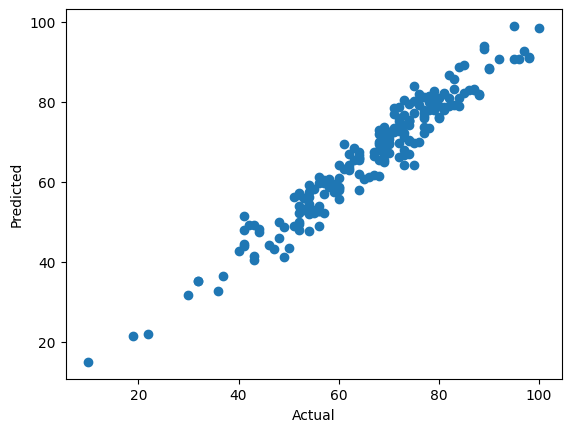

In [14]:
#plot y_pred and y_test
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

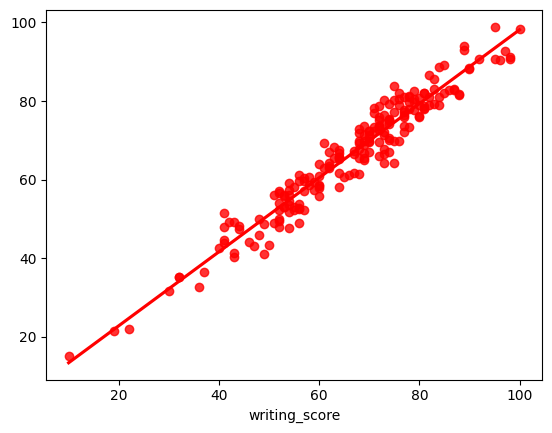

In [15]:
import seaborn as sns
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [16]:
# now finding the difference between actual and predicted 
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,84,88.634480,-4.634480
737,73,66.631764,6.368236
740,72,73.579121,-1.579121
660,73,71.251040,1.748960
411,78,79.864976,-1.864976
...,...,...,...
408,56,61.104902,-5.104902
332,53,56.064994,-3.064994
208,76,79.073317,-3.073317
613,74,75.164915,-1.164915
